# Fund Workstation

### Setting Up the Environment

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from src.fofproject.fund import Fund, input_monthly_returns, subset_of_funds, compare_funds
from fofproject.batch import plot_cumulative_returns, plot_fund_correlation_heatmap
from src.fofproject.mvo import minimum_variance_analysis
from src.fofproject.load import load_saved_json, init_funds, process_pdfs_in_folder, save_changes_in_fund, merge_funds, rerun_no_perf_files

# Names of our portfolio & benchmark indices
our_portfolio = ['TAIREN','HAO','LEXINGTON','LIM','FOREST','WT CHINA','E20','3W GLOBAL','3W CHINA','3W HEALTHCARE','TIMEFOLIO','MONOLITH','PERSEVERANCE','NEO IVY','JH BIOTECH']
our_index = ['MSCI CHINA','TOPIX','S&P 500','MSCI WORLD', 'EUREKAHEDGE']

#### Load Data via .json

In [11]:
test = load_saved_json(folder_path=r"input\worth_a_look")
funds = init_funds(test)


In [12]:
port = load_saved_json(folder_path=r"input\portfolio")
port = init_funds(port)
funds = funds | port

#### Load Data via .csv

In [15]:
# Use for manually update csv data and merge with json file 

csv_fund = input_monthly_returns(r"RETURN DATA.csv")



#### GPT Input Factsheet

In [2]:
# Do not open the pdf while running, or the renaming process will encounter error
gpt_fund = process_pdfs_in_folder(folder_path=r"input\re-run",save=True)
gpt_fund = init_funds(gpt_fund)

Processing: input\re-run\ASIAN TECHNOLOGY_parsed from_ASIAN TECHNOLOGY_ASIA_EquityLS_30% vol.pdf
text parsing - the result is {
  "fund_name": "ASIAN TECHNOLOGY",
  "fund_des": "ASIAN TECHNOLOGY ABSOLUTE RETURN FUND (ATF) is a specialist equity long/short hedge fund focusing on hardware technology companies primarily in Taiwan, US, and HK/China. The fund employs a top-down approach to identify key technology trends and a bottoms-up fundamental analysis to invest in market leaders and technology pioneers with high growth potential. Managed by experienced professionals based in Hong Kong, the fund targets a net exposure of 30% to 70% and aims for concentrated investments in technology sub-segments. Rated 4 for its focused strategy and experienced management team.",
  "performance": {
    "table": [
      ["Year", "01/01", "01/02", "01/03", "01/04", "01/05", "01/06", "01/07", "01/08", "01/09", "01/10", "01/11", "01/12", "Year"],
      ["2025", "-0.0486", "-0.0878", "-0.0595", "0.0235", "0

In [4]:
port = load_saved_json(folder_path=r"input\portfolio")
port = init_funds(port)
funds = gpt_fund | port

In [35]:
# Target the files with "No Performance Found", and re-run the analysis again
rerun_no_perf_files(folder_path=r"input\worth_a_look",save=True)

Re-processing (no performance before): input\worth_a_look\PALOMA_parsed from_PALOMA_Gloabl_Multi-strat_10%rtn 5% vol.pdf
text parsing - the result is {
  "fund_name": "PALOMA",
  "fund_des": "PALOMA is a multi-strategy hedge fund focused on dynamic capital allocation across quantitative, equity long-short, and liquid credit strategies. Founded by S. Donald Sussman, it emphasizes risk management and diversified sector exposure including consumer, energy, financials, healthcare, and technology. The fund targets global investments and aims for attractive long-term risk-adjusted returns. Rating: 4/5, overall positive view due to strong legacy and diversified approach.",
  "performance": {
    "table": [
      ["Year", "01/01", "02/01", "03/01", "04/01", "05/01", "06/01", "07/01", "08/01", "09/01", "10/01", "11/01", "12/01", "Year"],
      ["2025", "0.0138", "0.0033", "-0.0141", "-0.0055", "0.0049", "0.0077", "0.0099"],
      ["2024", "0.0031", "-0.0041", "0.0089", "-0.0009", "0.0101", "-0.

[{'fund_name': 'PALOMA',
  'fund_des': 'PALOMA is a multi-strategy hedge fund focused on dynamic capital allocation across quantitative, equity long-short, and liquid credit strategies. Founded by S. Donald Sussman, it emphasizes risk management and diversified sector exposure including consumer, energy, financials, healthcare, and technology. The fund targets global investments and aims for attractive long-term risk-adjusted returns. Rating: 4/5, overall positive view due to strong legacy and diversified approach.',
  'performance': [{'date': '31/07/1984', 'value': 0.035},
   {'date': '31/08/1984', 'value': 0.026},
   {'date': '30/09/1984', 'value': 0.035},
   {'date': '31/10/1984', 'value': 0.011},
   {'date': '30/11/1984', 'value': 0.008},
   {'date': '31/12/1984', 'value': 0.013},
   {'date': '31/01/1985', 'value': 0.018},
   {'date': '28/02/1985', 'value': 0.018},
   {'date': '31/03/1985', 'value': 0.02},
   {'date': '30/04/1985', 'value': 0.003},
   {'date': '31/05/1985', 'value'

#### Process Input

In [ ]:
# Use the former file's performance data to update the latter one
funds = merge_funds(csv_fund, funds)

In [16]:
funds = csv_fund | funds

#### Save the Changes

In [ ]:
# Careful what fund you are saving to what folder
save_changes_in_fund(funds, folder_path=r"input\test")

⚠️ Skipping PALOMA (no performance data).
✅ No existing CSV found. Created new CSV at input\worth_a_look\returns.csv


In [5]:
print(funds['ASIAN TECHNOLOGY'].total_max_dd)

0.6246703569211681


### Compare Multiple Funds

In [13]:
df = compare_funds(funds)
df = df[~df["Name"].isin(our_index)].reset_index(drop=True)
df

,Name,Description,Location,Strategy,Sector,Managers,Contact,AUM (in Mn USD),Net Exposure,Net Return,...,Inception Date,Latest Date,# Months,Cumulative Return,Annualized Return,Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Positive Months
0,3W CHINA,3W Greater China Focus Fund is a long/short eq...,[apac],[equity_ls],[equity_diversified],None,"{'name': '', 'location': 'Hong Kong', 'email':...",920.52,[0.2325],True,...,2012-03-01,2025-08-01,162,4.133456,0.128815,0.074835,1.721337,3.696521,0.096000,0.691358
1,3W GLOBAL,3W Global Fund is a long/short equity fund man...,[apac],[equity_ls],[equity_diversified],3W Fund Management Limited,"{'name': '', 'location': 'Hong Kong', 'email':...",2160.97,[0.2101],True,...,2015-02-01,2025-08-01,127,6.384341,0.207940,0.131453,1.581857,4.632756,0.106092,0.692913
2,3W HEALTHCARE,3W Healthcare Fund is a healthcare-focused equ...,[apac],[equity_ls],[equity_healthcare],3W Fund Management Limited,"{'name': '', 'location': 'Hong Kong', 'email':...",86.42,[0.3614],True,...,2021-02-01,2025-08-01,55,0.103619,0.021745,0.206779,0.105159,0.143744,0.544285,0.600000
3,APEX,"APEX is a systematic, multi-strategy hedge fun...",[global],"[systematic, multi-strat]",equity_diversified,"Jorge Fernandez Cuervo, Cameron McElroy","{'name': 'Jorge Fernandez Cuervo', 'location':...",4283.00,[0],True,...,2020-04-01,2025-06-01,63,1.452383,0.186335,0.087386,2.132319,4.723199,0.061645,0.730159
4,ARVIN,ARVIN is a hedge fund focused on equity long/s...,"[north_america, global]","[equity_ls, special_situation]","[equity_consumer, equity_industrials, equity_T...","Rohan Varavadekar, Christopher Bonanni","{'name': 'Rohan Varavadekar', 'location': 'Aus...",508.00,"[0.3, 0.65]",True,...,2021-06-01,2025-06-01,49,0.686744,0.136590,0.103109,1.324715,3.031259,0.084283,0.673469
5,ASIAN ALPHA,ASIAN ALPHA is an equity long/short hedge fund...,[apac],[equity_ls],[equity_diversified],"Andrew Alexander, Raymond Chan, Patrick Cheung...","{'name': 'Andrew Alexander', 'location': 'Hong...",72.00,"[-0.1, 0.1]",True,...,2022-09-01,2025-06-01,34,0.522823,0.160017,0.056688,2.822794,10.099125,0.023961,0.794118
6,BWCP,"BWCP is a fundamentally based, concentrated eq...",[global],[equity_ls],"[equity_TMT, equity_consumer]","Brandon Wier, Rob Giacobbe, Neel Tanna, Brian ...","{'name': 'Rob Giacobbe', 'location': 'Dallas, ...",142.00,"[0.2, 0.4]",True,...,2020-01-01,2025-06-01,66,0.934273,0.127442,0.114993,1.108258,2.035353,0.179130,0.590909
7,CALIGAN,"Caligan is a concentrated, long-biased hedge f...","[north_america, europe]","[equity_ls, special_situation, multi-strat]",[equity_healthcare],"David Johnson, Robert Laman, Charlie Lee, Tiff...","{'name': 'Robert Laman', 'location': 'New York...",370.00,"[0.65, 0.85]",False,...,2022-01-01,2025-06-01,42,1.310047,0.270257,0.194869,1.386867,2.857106,0.161700,0.666667
8,CARTENNA CAPITAL,Cartenna Capital is a long/short equity hedge ...,"[north_america, europe]","[equity_ls, fundamental]","[equity_industrials, equity_consumer]","Peter Avellone, Ryan Molloy, David Hoffman, Jo...","{'name': 'Sean McDuffy', 'location': 'Stamford...",147.70,"[0.1, 0.25]",True,...,2020-04-01,2025-06-01,63,0.769120,0.114787,0.053148,2.159765,4.880723,0.040000,0.761905
9,CENTIVA,"CENTIVA is a diversified, absolute return orie...",[global],[multi-strat],equity_diversified,"Edward McBride, Karim Abbadi","{'name': 'Deepa Bhattacharjee Sarkar', 'locati...",2840.00,[0],True,...,2017-03-01,2025-06-01,100,0.710767,0.066554,0.029725,2.239032,6.576854,0.027108,0.700000


In [14]:
# Combine all conditions in a single filter
mask = (df["Sharpe Ratio"] > 1) & (df["Annualized Return"] > 0.1) & (df["AUM (in Mn USD)"] > 10) 

# Column List = ["Name", "Description", "Location", "Strategy", "Sector", "Managers", "Contact", "AUM (in Mn USD)", 
#                     "Net Exposure", "Net Return", "Mgmt Fee", "Perf Fee", "Inception Date", "Latest Date", 
#                     "# Months", "Cumulative Return", "Annualized Return", "Volatility", "Sharpe Ratio", 
#                     "Sortino Ratio", "Max Drawdown", "Positive Months"]

# Then, select only the columns you want
df['Worth a Look'] = mask
filtered = df[["Worth a Look","Name", "Location","Strategy", "AUM (in Mn USD)", "Sharpe Ratio", "Annualized Return", "Max Drawdown","Description"]]
filtered

,Worth a Look,Name,Location,Strategy,AUM (in Mn USD),Sharpe Ratio,Annualized Return,Max Drawdown,Description
0,True,3W CHINA,[apac],[equity_ls],920.52,1.721337,0.128815,0.096000,3W Greater China Focus Fund is a long/short eq...
1,True,3W GLOBAL,[apac],[equity_ls],2160.97,1.581857,0.207940,0.106092,3W Global Fund is a long/short equity fund man...
2,False,3W HEALTHCARE,[apac],[equity_ls],86.42,0.105159,0.021745,0.544285,3W Healthcare Fund is a healthcare-focused equ...
3,True,APEX,[global],"[systematic, multi-strat]",4283.00,2.132319,0.186335,0.061645,"APEX is a systematic, multi-strategy hedge fun..."
4,True,ARVIN,"[north_america, global]","[equity_ls, special_situation]",508.00,1.324715,0.136590,0.084283,ARVIN is a hedge fund focused on equity long/s...
5,True,ASIAN ALPHA,[apac],[equity_ls],72.00,2.822794,0.160017,0.023961,ASIAN ALPHA is an equity long/short hedge fund...
6,True,BWCP,[global],[equity_ls],142.00,1.108258,0.127442,0.179130,"BWCP is a fundamentally based, concentrated eq..."
7,True,CALIGAN,"[north_america, europe]","[equity_ls, special_situation, multi-strat]",370.00,1.386867,0.270257,0.161700,"Caligan is a concentrated, long-biased hedge f..."
8,True,CARTENNA CAPITAL,"[north_america, europe]","[equity_ls, fundamental]",147.70,2.159765,0.114787,0.040000,Cartenna Capital is a long/short equity hedge ...
9,False,CENTIVA,[global],[multi-strat],2840.00,2.239032,0.066554,0.027108,"CENTIVA is a diversified, absolute return orie..."


In [ ]:
max_row = df.loc[df["Inception Date"].idxmax()]
print(min_row)
min_row = df.loc[df[" Latest Date"].idxmin()]
print(min_row)

#### Save it to CSV

In [ ]:
filtered.to_csv("output/funds_comparison.csv", index=False)

#### Print a list of worth looking funds

In [19]:
exclude_list = our_index + our_portfolio
df = df[~df["Name"].isin(exclude_list)].reset_index(drop=True)
worth_looking = df.loc[df["Worth a Look"], "Name"].tolist()
print(worth_looking)

['APEX', 'ARVIN', 'ASIAN ALPHA', 'BWCP', 'CALIGAN', 'CARTENNA CAPITAL', 'CFM CUMULUS', 'EGERTON', 'ENGINE CAPITAL', 'GLOBAL OPPORTUNITIES', 'HELIUM', 'HIDDENITE', 'KAPITALO', 'KATHMANDU', 'MOAT CAPITAL', 'MULTI-ALPHA', 'POLAR MULTI-STRATEGY', 'RIVERMONT', 'RUBRIC CAPITAL', 'SCULPTOR', 'SELIGMAN HEALTHCARE', 'SOLEUS CAPITAL', 'TCIM', 'THINK INVESTMENTS', 'VAR AI', 'WINDWARD', 'WOLF HILL', 'WT CHINA']


#### Compare Performance Table

In [ ]:
funds['RDGFF'].export_monthly_table(benchmark_fund = funds['MSCI CHINA'], benchmark_name = "MSCI\nChina" ,language = "en", inception_column = True)
funds['RDGFF'].export_monthly_table(benchmark_fund = funds['MSCI WORLD'], benchmark_name = "MSCI\nWorld" ,language = "en", inception_column = True)

#### Plot Cumulative Return

In [25]:

funds_to_be_plot = subset_of_funds(funds, worth_looking)
start_month = "2020-12"
end_month = "2025-7"

plot = plot_cumulative_returns(
    funds=funds_to_be_plot,
    title="",
    start_month=start_month,
    end_month=end_month,
    style="default",
    language="en",
    blur=False,
    aspect_lock=True,
    custom_ticks=False,
    save=False,
    toggle=True
    )


ValueError: start_month must be <= end_month

### Correlation Heat Map

In [23]:
# Correlation heatmap
list_to_plot = our_portfolio + ['BASSWOOD']
print(list_to_plot)
funds_to_be_plot = subset_of_funds(funds, list_to_plot)
start_month = "2019-12"
end_month = "2025-7"

fig, corr_df, overlap_df = plot_fund_correlation_heatmap(funds_to_be_plot, method="pearson", min_overlap=12)

['TAIREN', 'HAO', 'LEXINGTON', 'LIM', 'FOREST', 'WT LS', 'E20', '3W GLOBAL', '3W CHINA', '3W HEALTHCARE', 'TIMEFOLIO', 'MONOLITH', 'PERSEVERANCE', 'NEO IVY', 'JH BIOTECH', 'BASSWOOD']


AttributeError: 'NoneType' object has no attribute 'monthly_returns'

### Summary of a Fund

ARVIN is a hedge fund focused on equity long/short with opportunistic credit. Led by CIO Rohan Varavadekar with 20 years of experience, it employs a broad sourcing strategy targeting mispriced growth, value with catalysts, dislocations, and alpha shorts. The fund emphasizes deep underwriting, a 2-year IRR methodology, and tactical SPVs for unique market dislocations. It aims for high absolute returns with focused risk management. Rating: 4, positive outlook.
Net Exposure = 30.0% to 65.0%
{'name': 'Rohan Varavadekar', 'location': 'Austin, Texas, United States', 'email': '', 'number': ''}


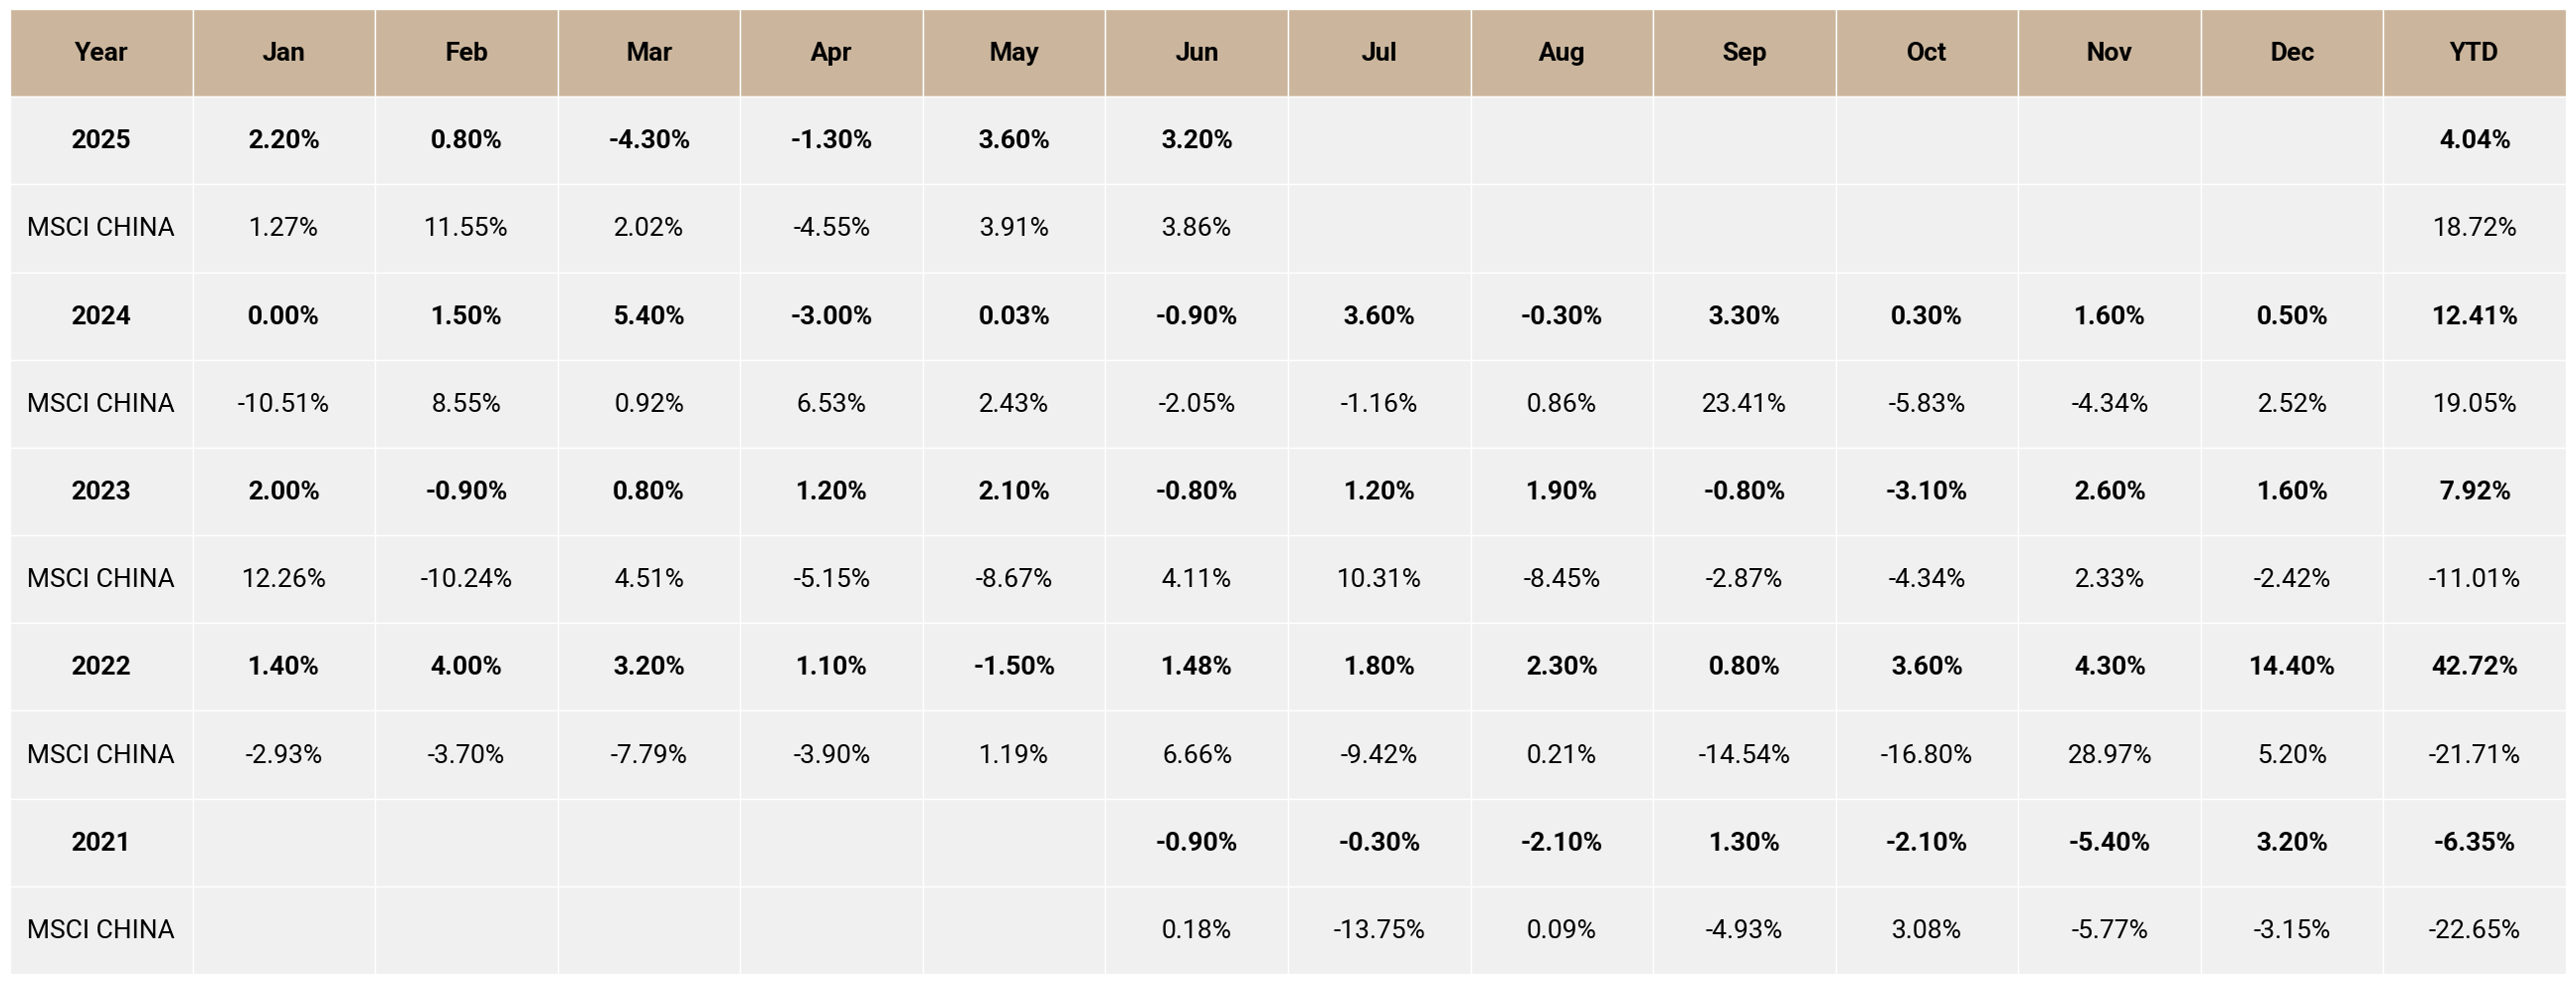

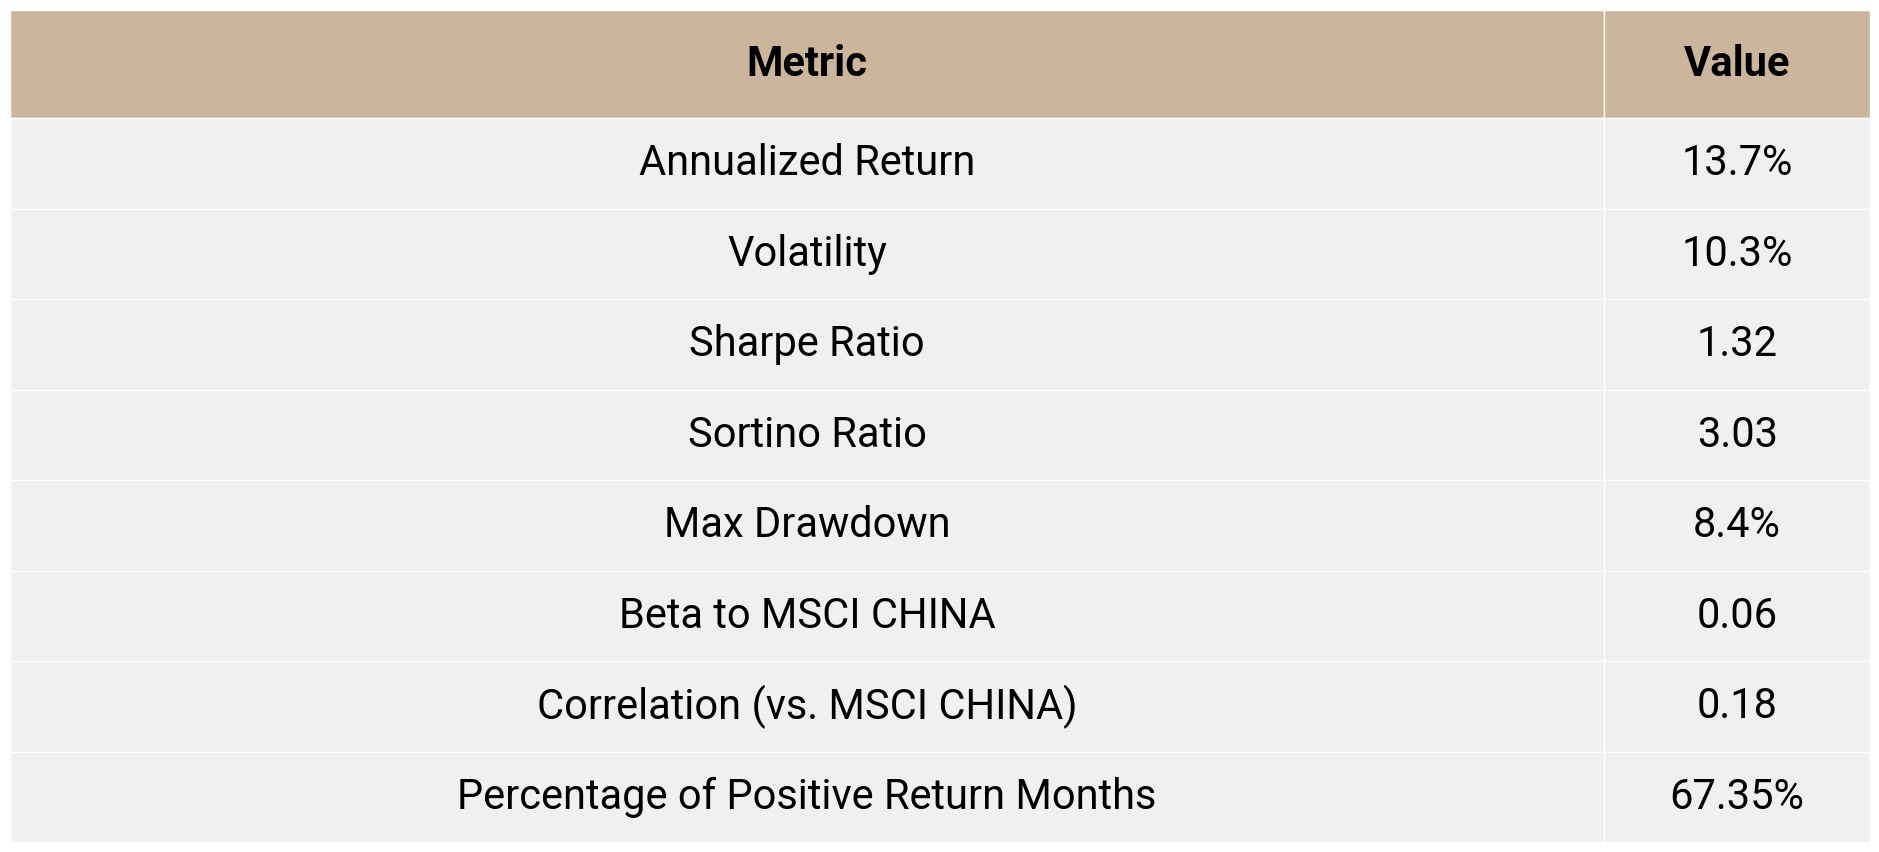

C:\Users\FOF Analyst\Desktop\fofproject\src\fofproject\fund.py:1447: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



In [19]:
funds['ARVIN'].summary_of_a_fund(benchmark_fund=funds['MSCI CHINA'],language="en")

#### Quick Investigation

In [ ]:
the_fund_to_investigate = funds['RDGFF']
benchmark_fund = funds['MSCI CHINA']
# The List = ["cagr","vol","sharpe","sortino","mdd","beta","corr","win","best","worst","aum","skew","kurt","turnover"]

fig = the_fund_to_investigate.export_key_metrics_table(
            benchmark_fund=benchmark_fund,
            end_month=the_fund_to_investigate.latest_date,
            language="en",
            metrics=["cagr", "vol", "sharpe", "sortino", "mdd", "beta", "corr", "win"],
            horizontal=False,
        )